In [105]:
"""
@author Kevin Nguyen
"""
# Necessary Imports
import pandas as pd
import utilities
import numpy as np
from xgboost import XGBRegressor

df = utilities.combine_data_folder()
df = df[df['Year'] > 2003]   

## Get the final DataFrame that is used
I wanted to add one more feature, previous seeds. I did not consider this before making my webscrape+combine functions. I add it here now.

In [42]:
# Add previous seed to df
previous_seeds_df = utilities.previous_seeds()
df = pd.merge(df, previous_seeds_df, how='outer', on=['Team', 'Year'])


# Predicting the NBA MVP

To start off the project, we need to consider some form of validation before deciding anything else. Because the data is season oriented, we want to use time cross validation instead of the normal k-fold cross validation. This is to prevent data leakage: future seasons should not influence the prediction of past seasons. Since there are a different different number of players in each season, the imported time cross validation will not do. The splits using that library are usually uniform. Here I implemented a time cross validation function that will suffice for the project.

In [67]:
# A function that preforms time cross validation on special NBA data
# Input: Regression 'model' to be tested, 'df' containing the data
# Output: A list of objects: 
def time_cross_validation(model, df=None, features=None):
    
    if features is None:
        features = [feature for feature in df.columns.to_list() if feature not in ['Player', 'Share', 'Year', 'Team']]
    
    years = list(range(2005, 2025))
    results = []
    score=[]
    right, wrong, right_10, wrong_10 = 0, 0, 0, 0

    for year in years:
        train_df = df[df['Year'] < year]
        test_df = df[df['Year'] == year]
        
        X_train = train_df[features]
        y_train = train_df['Share'] 

        X_test = test_df[features]
        y_test = test_df['Share']

        model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
        y_pred = model.predict(X_test)
        rmse = np.sqrt(np.mean((np.array(y_test) - np.array(y_pred))**2))

        test_copy = test_df.copy()
        test_copy['Predicted Share'] = y_pred
        actual_mvp = test_copy.sort_values('Share', ascending=False).iloc[0]['Player']
        actual_top_five = test_copy.sort_values('Share', ascending=False).iloc[0:5]['Player'].to_list()
        predicted_mvp = test_copy.sort_values('Predicted Share', ascending=False).iloc[0]['Player']
        predicted_top_five = test_copy.sort_values('Predicted Share', ascending=False).iloc[0:5]['Player'].to_list()

        results.append({
            "Train Years": [2004, year-1],
            "Test Year": year,
            "RMSE": rmse,
            "Predicted MVP": predicted_mvp,
            "Actual MVP": actual_mvp,
            "Predicted Top Five": predicted_top_five,
            "Actual Top Five": actual_top_five, 
        })

        score.append(rmse)

        if year == 2024:
            feature_importances = model.feature_importances_

        if predicted_mvp == actual_mvp:
            right += 1
        else:
            wrong += 1
        accuracy = right / 20

        if year >= 2015:
            if predicted_mvp == actual_mvp:
                right_10 += 1
            else:
                wrong_10 += 1
        accuracy_10  = right_10 / 10

    print("Last 20 Years: Right: " + str(right) + ", Wrong: " + str(wrong) + ' == accuracy: ' + str(round((accuracy), 3)))
    print("Last 10 Year: Right: " + str(right_10) + ", Wrong: " + str(wrong_10) + ' == accuracy: ' + str(round((accuracy_10), 3)))


    return results, feature_importances


In [ ]:
# Add previous seed to df
previous_seeds_df = utilities.previous_seeds()
df = pd.merge(df, previous_seeds_df, how='outer', on=['Team', 'Year'])


The function obviously returns the result of each validation split. Specifically, it will return an entire list of all the validations and their specifics, so we can point out any problems that might occur. For example, we might predict the winner correctly most of the time, but the predicted top five might be entirely different from the actual top five, in which case, the model is somewhat overfitting/malfunctioning. It will also print how many validations sets were correct.
But in order to do feature selection, the function will also return feature importances. From that, the top 5-7 are chosen in order to possibly reduce accuracy.

XGBoost will be the model we use. Since we do not have a lot of data, a Neural Network would be overkill. A RandomForest is usuable, but I decided on XGBoost because it works well with tabular data and preforms better in general (from what I've read online).
####
First, we will use the XBGRegressor model without tuning (tuning will come later) and with all functions.

Last 20 Years: Right: 12, Wrong: 8 == accuracy: 0.6
Last 10 Year: Right: 8, Wrong: 2 == accuracy: 0.8


eFG%             0.007182
GS               0.007302
WS/48            0.007359
TRB              0.007954
FG%              0.008247
DRB%             0.009887
MP               0.010278
BLK%             0.011303
PTS              0.012510
USG%             0.013881
DWS              0.014613
WS               0.015583
FT%              0.016846
Previous Seed    0.019559
AST              0.023196
STL%             0.026282
W/L%             0.047913
PER              0.106216
Seed             0.141291
VORP             0.464459
dtype: float32

[{'Train Years': [2004, 2004],
  'Test Year': 2005,
  'RMSE': 0.06389902093850464,
  'Predicted MVP': 'Kevin Garnett',
  'Actual MVP': 'Steve Nash',
  'Predicted Top Five': ['Kevin Garnett',
   'Ben Wallace',
   'Jackie Butler',
   'Donnell Harvey',
   "Amar'e Stoudemire"],
  'Actual Top Five': ['Steve Nash',
   "Shaquille O'Neal",
   'Dirk Nowitzki',
   'Tim Duncan',
   'Allen Iverson']},
 {'Train Years': [2004, 2005],
  'Test Year': 2006,
  'RMSE': 0.047268859520363075,
  'Predicted MVP': 'Chauncey Billups',
  'Actual MVP': 'Steve Nash',
  'Predicted Top Five': ['Chauncey Billups',
   'LeBron James',
   'Kobe Bryant',
   'Dwyane Wade',
   'Dirk Nowitzki'],
  'Actual Top Five': ['Steve Nash',
   'LeBron James',
   'Dirk Nowitzki',
   'Kobe Bryant',
   'Chauncey Billups']},
 {'Train Years': [2004, 2006],
  'Test Year': 2007,
  'RMSE': 0.019816503526918997,
  'Predicted MVP': 'Dirk Nowitzki',
  'Actual MVP': 'Dirk Nowitzki',
  'Predicted Top Five': ['Dirk Nowitzki',
   'Steve Nash',
   

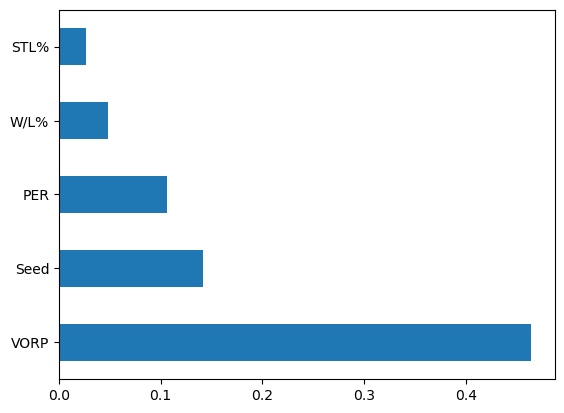

In [68]:
model = XGBRegressor()
features = [feature for feature in df.columns.to_list() if feature not in ['Player', 'Share', 'Year', 'Team']]
results, feature_importances = time_cross_validation(model, df, features)

feat_importances = pd.Series(feature_importances, index=features).sort_values()
feat_importances.nlargest(5).plot(kind='barh')
display(feat_importances.tail(20))
results

The results so us a number of things. Eariler on, the model does not predict very accurately much at all. It could not guess the mvps correctly nor guess the top 5. This might be due to un-feature selected data that might skew the predictions. Later on, as the years progressed, the data became more fit on more data and started to produce correct mvps, with reasonable top 5s. From the feature importances, we can see that VORP, or Value Over Replacement Player, is the most influential in deciding the MVP. This obviously makes sense, along with PER (Player Efficiency Rating). However, not all features that are heavily weighed are good. An example would be the steal percentage; not every mvp steals frequently. Also, games played should be more impactful; this will be taken care of in the feature selection process.
####
In the end we can see that in the years 2004-2024, the accuracy was at a disappointing 60%. But the model's accuracy in the years 2014-2024 was better at 80%.
####
Slightly less important, we can see how narrative affects some years. For example, Steve Nash did not have the 'best' stats spread compared to the others (i.e. Kobe), but he lead his team to a winning record in those years despite down other valuable teammates. Also Kobe had that rape case allegation, so nobody would want to give it to him.

Next, feature selection. Trimming the dataset with given mvp statistics will reduce the error incrementally. An example would be a player is eligible for mvp only after he has played more than 65 games during the season (there are some exceptions for the injured).\
Also, using domain expertise, many other features are eliminated in order to pursue accuracy. Some features will be graphed to illustrate their correlation.

In [97]:
model = XGBRegressor()
df_new = df.copy()
df_new = df_new[df_new['GS'] >= 41]
df_new = df_new[df_new['G'] > 65]
df_new = df_new[df_new['MP'] > 25]
df_new = df_new[df_new['MP'] * df_new['G'] > 41]

features = ['VORP', 'W/L%', 'USG%', 'WS/48', 'PER', 'Seed']
results, feature_importances = time_cross_validation(model, df_new, features)
results


Last 20 Years: Right: 16, Wrong: 4 == accuracy: 0.8
Last 10 Year: Right: 9, Wrong: 1 == accuracy: 0.9


[{'Train Years': [2004, 2004],
  'Test Year': 2005,
  'RMSE': 0.11463679190585142,
  'Predicted MVP': "Amar'e Stoudemire",
  'Actual MVP': 'Steve Nash',
  'Predicted Top Five': ["Amar'e Stoudemire",
   'Dwyane Wade',
   'Tim Duncan',
   "Shaquille O'Neal",
   'Allen Iverson'],
  'Actual Top Five': ['Steve Nash',
   "Shaquille O'Neal",
   'Dirk Nowitzki',
   'Tim Duncan',
   'Allen Iverson']},
 {'Train Years': [2004, 2005],
  'Test Year': 2006,
  'RMSE': 0.09179482208527132,
  'Predicted MVP': 'Dwyane Wade',
  'Actual MVP': 'Steve Nash',
  'Predicted Top Five': ['Dwyane Wade',
   'Dirk Nowitzki',
   'LeBron James',
   'Kobe Bryant',
   'Chauncey Billups'],
  'Actual Top Five': ['Steve Nash',
   'LeBron James',
   'Dirk Nowitzki',
   'Kobe Bryant',
   'Chauncey Billups']},
 {'Train Years': [2004, 2006],
  'Test Year': 2007,
  'RMSE': 0.11336994538161087,
  'Predicted MVP': 'Zach Randolph',
  'Actual MVP': 'Dirk Nowitzki',
  'Predicted Top Five': ['Zach Randolph',
   'Dirk Nowitzki',
   '

We can see that the accuracy has improved to 80% on the 20 years and to 90% on the last 10 years due to the feature selection. Mostly all the top 5s are reasonable based on my knowledge; exception for the early years.\
####
Lastly, fine tuning hyperparameters for XGBoost might lead to a slight increase in accuracy. 

In [104]:
param_grid = [
    # Shallow trees, fewer estimators
    {'max_depth': 3, 'learning_rate': 0.1, 'n_estimators': 100, 'subsample': 0.8},
    {'max_depth': 3, 'learning_rate': 0.05, 'n_estimators': 300, 'subsample': 0.9},
    

    # Medium trees, steady LR
    {'max_depth': 4, 'learning_rate': 0.07, 'n_estimators': 200, 'subsample': 0.8},
    {'max_depth': 4, 'learning_rate': 0.1, 'n_estimators': 200, 'subsample': 0.9},
    {'max_depth': 4, 'learning_rate': 0.1, 'n_estimators': 300, 'subsample': 1.0},

    # Deeper trees
    {'max_depth': 5, 'learning_rate': 0.07, 'n_estimators': 300, 'subsample': 0.9},
    {'max_depth': 5, 'learning_rate': 0.05, 'n_estimators': 400, 'subsample': 0.8},
    {'max_depth': 5 ,'learning_rate': 0.1,'n_estimators': 300, 'subsample': 0.8},

    {'max_depth': 6, 'learning_rate': 0.03, 'n_estimators': 500, 'subsample': 0.9},
    {'max_depth': 6, 'learning_rate': 0.05, 'n_estimators': 400, 'subsample': 0.7},
    

    # Balanced alternative subsample values
    {'max_depth': 4, 'learning_rate': 0.1, 'n_estimators': 300, 'subsample': 0.7},
    {'max_depth': 5, 'learning_rate': 0.1, 'n_estimators': 200, 'subsample': 0.7},
]

results_summary = []

df_new = df.copy()
df_new = df_new[df_new['GS'] >= 41]
df_new = df_new[df_new['G'] > 65]
df_new = df_new[df_new['MP'] > 25]
df_new = df_new[df_new['MP'] * df_new['G'] > 41]

features = ['VORP', 'W/L%', 'USG%', 'WS/48', 'PER', 'Seed']

for i, params in enumerate(param_grid):
    print(f"\n Testing Param Set {i+1}: {params}")
    model = XGBRegressor(objective='reg:squarederror', **params)
    results, feature_importances = time_cross_validation(model, df_new, features)

    # Compute average RMSE
    avg_rmse = np.mean([res['RMSE'] for res in results])
    
    results_summary.append({
        'params': params,
        'avg_rmse': avg_rmse,
        'last_year_predicted_mvp': results[-1]['Predicted MVP'],
        'last_year_actual_mvp': results[-1]['Actual MVP'],
    })

# Print results
print("\n Summary of All Runs:")
for res in results_summary:
    print(f"{res['params']} -> Avg RMSE: {round(res['avg_rmse'], 4)}, 2024 MVP: {res['last_year_predicted_mvp']}")


 Testing Param Set 1: {'max_depth': 3, 'learning_rate': 0.1, 'n_estimators': 100, 'subsample': 0.8}
Last 20 Years: Right: 16, Wrong: 4 == accuracy: 0.8
Last 10 Year: Right: 9, Wrong: 1 == accuracy: 0.9

 Testing Param Set 2: {'max_depth': 3, 'learning_rate': 0.05, 'n_estimators': 300, 'subsample': 0.9}
Last 20 Years: Right: 16, Wrong: 4 == accuracy: 0.8
Last 10 Year: Right: 8, Wrong: 2 == accuracy: 0.8

 Testing Param Set 3: {'max_depth': 4, 'learning_rate': 0.07, 'n_estimators': 200, 'subsample': 0.8}
Last 20 Years: Right: 15, Wrong: 5 == accuracy: 0.75
Last 10 Year: Right: 8, Wrong: 2 == accuracy: 0.8

 Testing Param Set 4: {'max_depth': 4, 'learning_rate': 0.1, 'n_estimators': 200, 'subsample': 0.9}
Last 20 Years: Right: 16, Wrong: 4 == accuracy: 0.8
Last 10 Year: Right: 8, Wrong: 2 == accuracy: 0.8

 Testing Param Set 5: {'max_depth': 4, 'learning_rate': 0.1, 'n_estimators': 300, 'subsample': 1.0}
Last 20 Years: Right: 16, Wrong: 4 == accuracy: 0.8
Last 10 Year: Right: 8, Wrong: 2

#### Conclusion:
Based on the results, the best hyperparameters are max_depth=5, learning rate=0.1, n_estimators=300, subsample=0.8 resulting in 85% accuracy for the last 20 years.\
In addition, the features selected (['VORP', 'W/L%', 'USG%', 'WS/48', 'PER', 'Seed']), is the other factor that affects the accuracy greatly.
The last thing left to do is to predict the 2025 MVP.